In [28]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=5)

In [29]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 1, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [30]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [31]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [32]:
intensity_matrix_quantum

Array([[[[0.+3.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-2.j, 0.+2.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-2.j, 0.+1.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-1.j, 0.-2.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-2.j, 0.-2.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-3.j]]]],      dtype=complex128)

In [33]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64),
 Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64))

In [34]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []
    for t in np.arange(1,20,0.1):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,20,0.1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [35]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d

,states,prior,time,real,imag
0,-3,Upper,0,-0.0009698304518587916,5.89534931288993e-19
1,-2,Upper,0,-0.002909491355576375,-0.005118661374815365
2,-1,Upper,0,0.015633096057400785,-0.025593306874076818
3,0,Upper,0,0.12095382899645078,0.004668614092033994
4,1,Upper,0,0.16613891518579585,0.31977538291667945
...,...,...,...,...,...
3985,-1,Lower,189,-0.17445286510380148,-0.07508373167352882
3986,0,Lower,189,0.2161976365834795,-0.14978388825719036
3987,1,Lower,189,-0.14636937100753183,0.08541991765058538
3988,2,Lower,189,0.07093056315661178,-0.0170839835301171


In [36]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [23]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #"browser"
fig = px.line_3d(df_quantum_3d.query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), x="Time", y="Real", z="Imaginary", color="states",
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Confidence States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=7
    ))
fig.update_layout(font=dict(
        
        size=15,  # Set the font size here
    ))
fig.show()

/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'http://127.0.0.1:41719'


In [39]:
df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

,states,prior,time,real,imag


In [10]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [41]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

,0,1,2,3,4,5,6
0,0.001904,0.001557,0.001440,0.001401,0.001388,0.001385,0.001384
1,0.007611,0.006224,0.005760,0.005605,0.005555,0.005541,0.005539
2,0.022821,0.018665,0.017280,0.016822,0.016675,0.016634,0.016628
3,0.068453,0.055988,0.051850,0.050489,0.050056,0.049935,0.049917
4,0.205407,0.168009,0.155616,0.151553,0.150267,0.149907,0.149856
5,0.616533,0.504289,0.467119,0.454951,0.451106,0.450031,0.449877
6,0.462703,0.378466,0.350574,0.341444,0.338560,0.337754,0.337639


In [42]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot

,states,prior,time,value
0,-3,Upper,0.0,0.000013
1,-2,Upper,0.0,0.000166
2,-1,Upper,0.0,0.001717
3,0,Upper,0.0,0.014567
4,1,Upper,0.0,0.096796
...,...,...,...,...
3985,-1,Lower,18.9,0.022821
3986,0,Lower,18.9,0.068451
3987,1,Lower,18.9,0.205394
3988,2,Lower,18.9,0.616488


/home/rkmalaiya/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



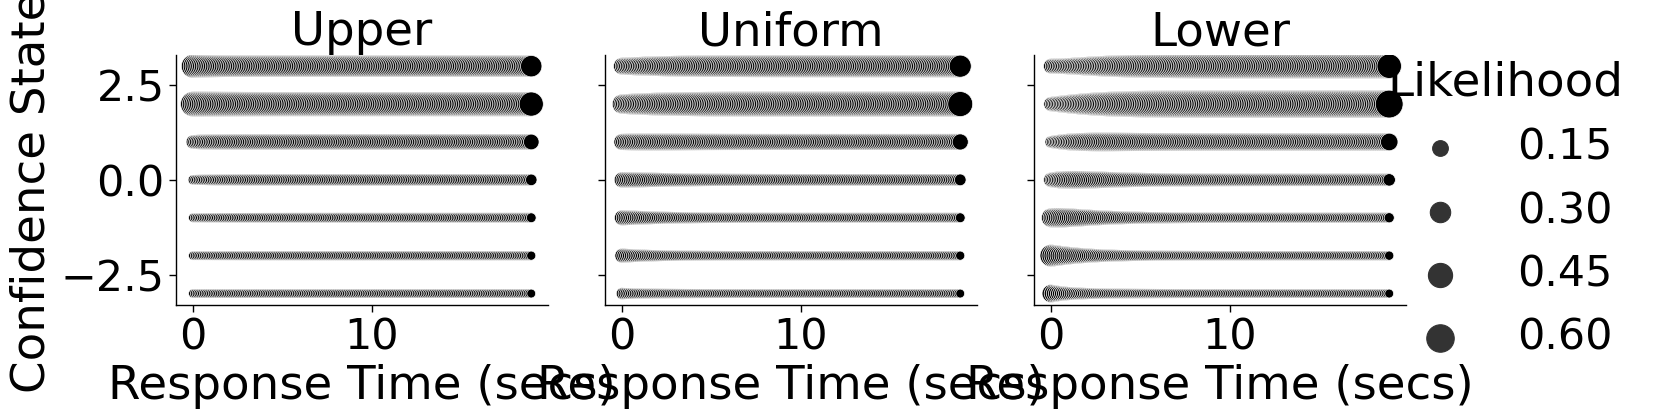

In [13]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [46]:
fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

/home/rkmalaiya/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



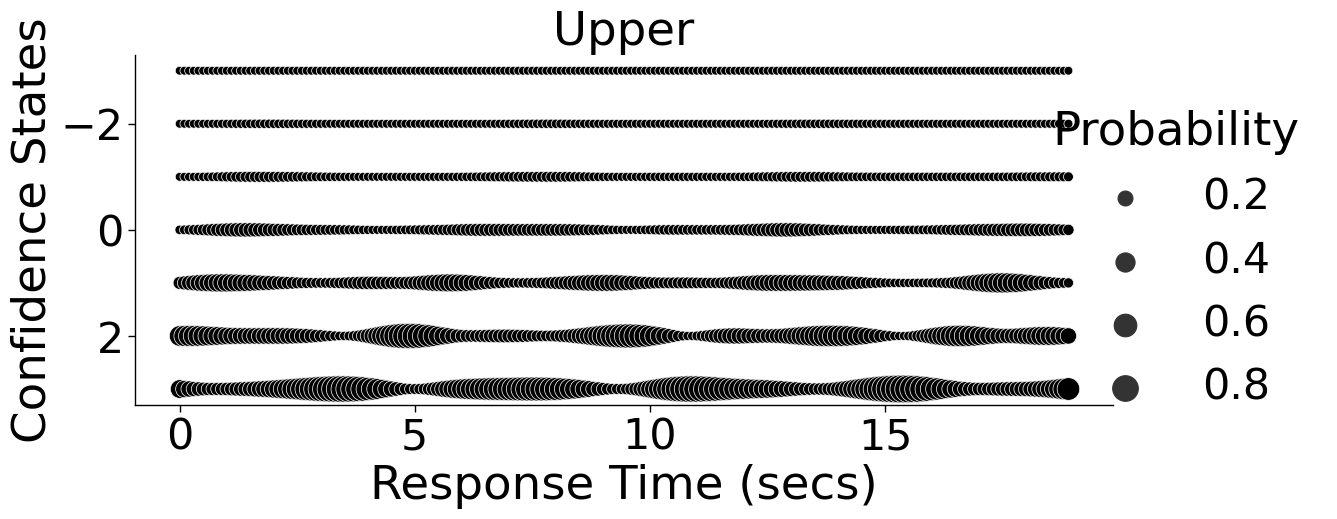

In [31]:
f = sns.relplot(df_quantum_plot.query("prior=='Upper'").astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=2, height = 6)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [ ]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

In [ ]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.01]]), npx.asarray([[0.1]]), npx.asarray([[0.5]]), npx.asarray([[1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []
        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(sigma_m[0,0])}")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(sigma_m[0,0])}")])
        

In [ ]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_markov1_plot.query("value > 3")

In [ ]:
df_markov1_plot

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i

In [ ]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()